California Housing Dataset - Quick EDA
Dataset shape: (20640, 9)

Columns: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude', 'MedHouseVal']

Basic Statistics:
             MedInc      HouseAge      AveRooms     AveBedrms    Population  \
count  20640.000000  20640.000000  20640.000000  20640.000000  20640.000000   
mean       3.870671     28.639486      5.429000      1.096675   1425.476744   
std        1.899822     12.585558      2.474173      0.473911   1132.462122   
min        0.499900      1.000000      0.846154      0.333333      3.000000   
25%        2.563400     18.000000      4.440716      1.006079    787.000000   
50%        3.534800     29.000000      5.229129      1.048780   1166.000000   
75%        4.743250     37.000000      6.052381      1.099526   1725.000000   
max       15.000100     52.000000    141.909091     34.066667  35682.000000   

           AveOccup      Latitude     Longitude   MedHouseVal  
count  20640.000

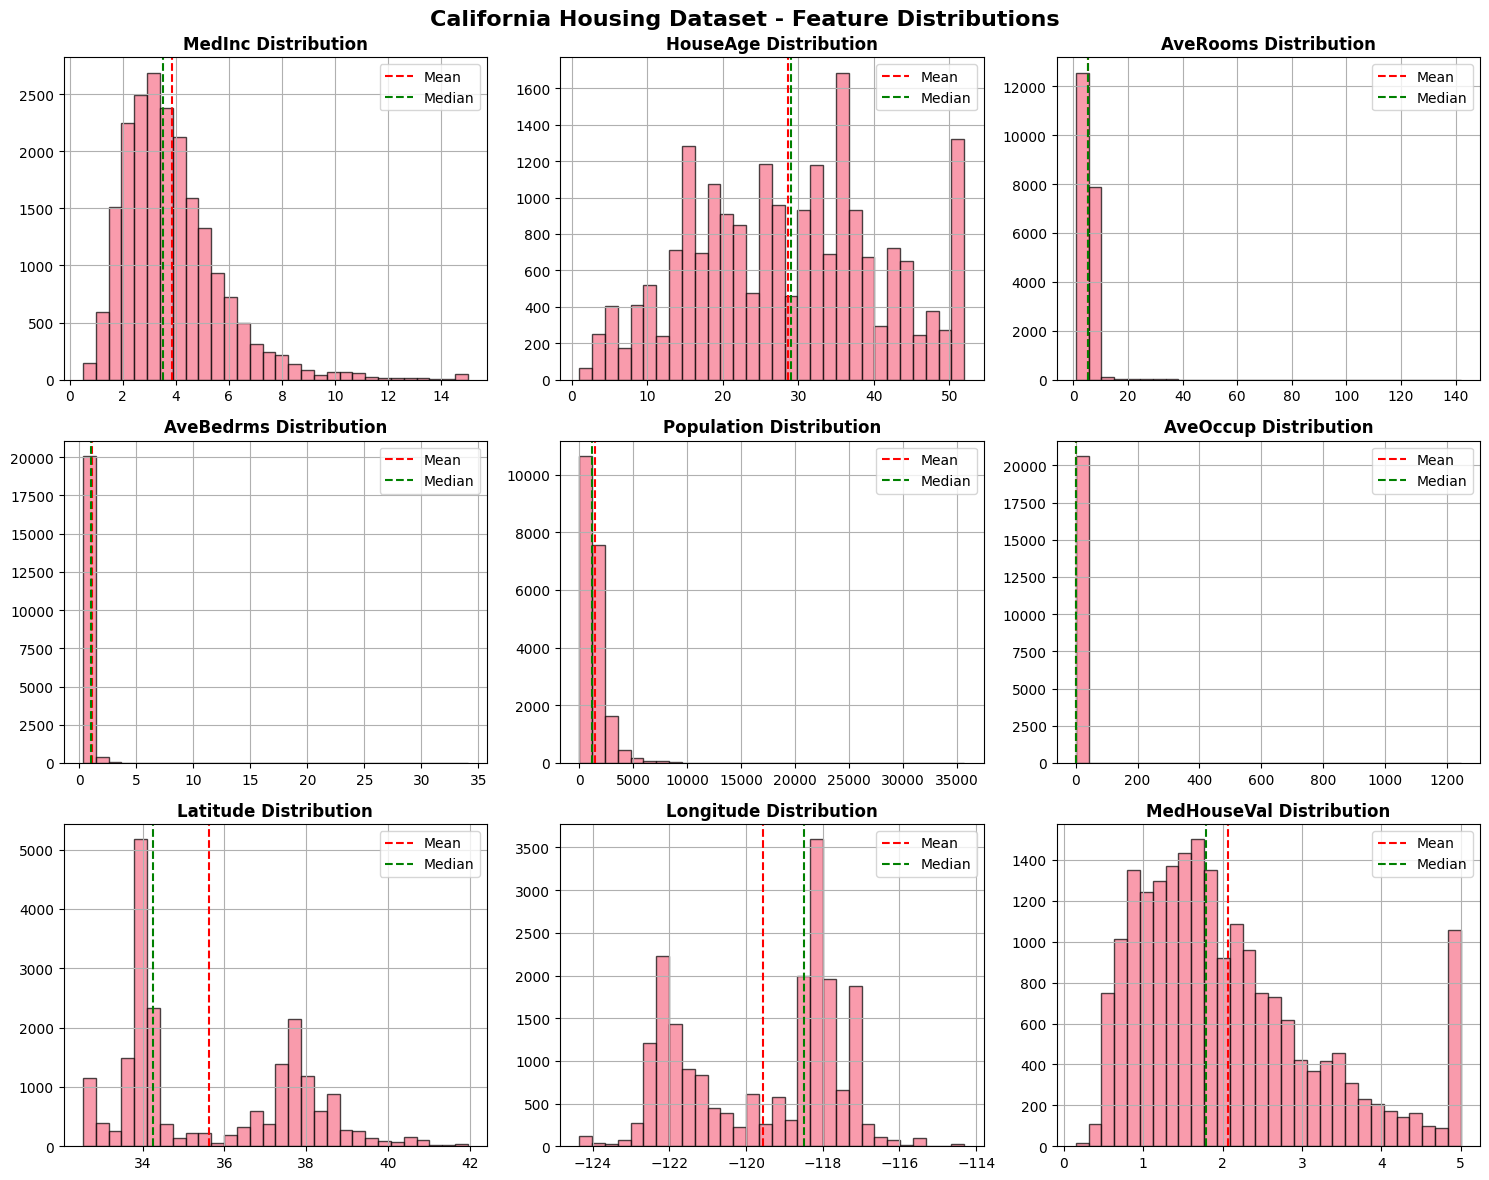

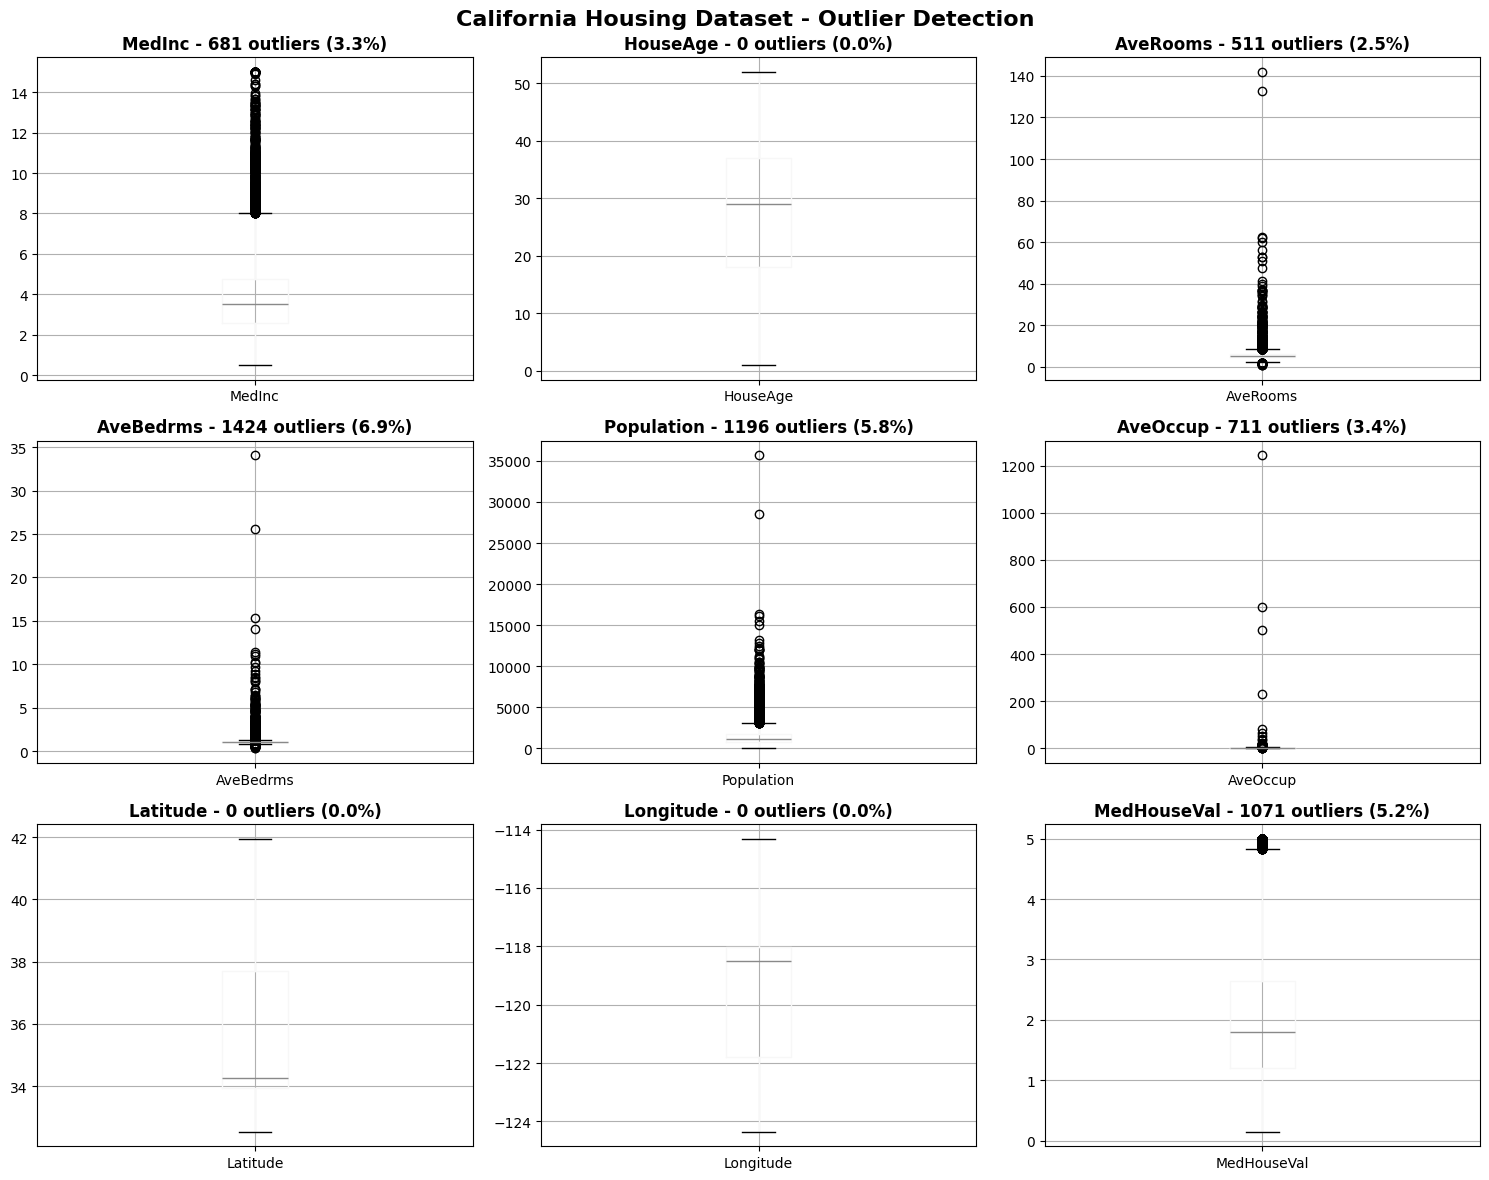


Outlier Summary:
MedInc: 681 outliers (3.3%)
HouseAge: 0 outliers (0.0%)
AveRooms: 511 outliers (2.5%)
AveBedrms: 1424 outliers (6.9%)
Population: 1196 outliers (5.8%)
AveOccup: 711 outliers (3.4%)
Latitude: 0 outliers (0.0%)
Longitude: 0 outliers (0.0%)
MedHouseVal: 1071 outliers (5.2%)

Plots saved successfully!
EDA completed.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing

# Set style
plt.style.use('default')
sns.set_palette("husl")


def load_data():
    """Load California Housing dataset"""
    data = fetch_california_housing()
    df = pd.DataFrame(data.data, columns=data.feature_names)
    df['MedHouseVal'] = data.target
    return df


def plot_histograms(df):
    """Plot histograms for all numerical features"""
    fig, axes = plt.subplots(3, 3, figsize=(15, 12))
    axes = axes.flatten()

    for i, col in enumerate(df.columns):
        ax = axes[i]
        df[col].hist(bins=30, ax=ax, alpha=0.7, edgecolor='black')
        ax.axvline(df[col].mean(), color='red',
                   linestyle='--', label='Mean')
        ax.axvline(df[col].median(), color='green',
                   linestyle='--', label='Median')
        ax.set_title(f'{col} Distribution', fontweight='bold')
        ax.legend()

    plt.suptitle(
        'California Housing Dataset - Feature Distributions',
        fontsize=16,
        fontweight='bold'
    )
    plt.tight_layout()
    plt.show()

    return fig


def plot_boxplots(df):
    """Plot boxplots for outlier detection"""
    fig, axes = plt.subplots(3, 3, figsize=(15, 12))
    axes = axes.flatten()

    outlier_info = {}

    for i, col in enumerate(df.columns):
        ax = axes[i]
        df.boxplot(column=col, ax=ax)

        # Calculate outliers
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1

        outliers = df[
            (df[col] < (Q1 - 1.5 * IQR)) |
            (df[col] > (Q3 + 1.5 * IQR))
        ]

        outlier_info[col] = {
            'count': len(outliers),
            'percentage': len(outliers) / len(df) * 100
        }

        ax.set_title(
            f'{col} - {len(outliers)} outliers '
            f'({outlier_info[col]["percentage"]:.1f}%)',
            fontweight='bold'
        )

    plt.suptitle(
        'California Housing Dataset - Outlier Detection',
        fontsize=16,
        fontweight='bold'
    )
    plt.tight_layout()
    plt.show()

    # Print outlier summary
    print("\nOutlier Summary:")
    for col, info in outlier_info.items():
        print(
            f"{col}: {info['count']} outliers "
            f"({info['percentage']:.1f}%)"
        )

    return fig, outlier_info


def main():
    """Main function"""

    print("California Housing Dataset - Quick EDA")
    print("=" * 50)

    # Load data
    df = load_data()

    print(f"Dataset shape: {df.shape}")
    print(f"\nColumns: {list(df.columns)}")

    # Basic stats
    print("\nBasic Statistics:")
    print(df.describe())

    # Check for missing values
    print(f"\nMissing values: {df.isnull().sum().sum()}")

    # Generate plots
    hist_fig = plot_histograms(df)
    box_fig, outliers = plot_boxplots(df)

    # Save plots
    hist_fig.savefig(
        'california_housing_histograms.png',
        dpi=150,
        bbox_inches='tight'
    )

    box_fig.savefig(
        'california_housing_boxplots.png',
        dpi=150,
        bbox_inches='tight'
    )

    print("\nPlots saved successfully!")
    print("EDA completed.")


if __name__ == "__main__":
    main()